In [3]:
import pandas as pd
import seaborn as sns

In [4]:
data = pd.read_csv("/content/train.csv")

In [5]:
data.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0.0
1,1,2013-01-01,1,BABY CARE,0.0,0.0
2,2,2013-01-01,1,BEAUTY,0.0,0.0
3,3,2013-01-01,1,BEVERAGES,0.0,0.0
4,4,2013-01-01,1,BOOKS,0.0,0.0


In [6]:
data.describe()

,id,store_nbr,sales,onpromotion
count,81886.000000,81886.000000,81886.000000,81885.0
mean,40942.500000,27.520321,190.048882,0.0
std,23638.596409,15.581416,648.706204,0.0
min,0.000000,1.000000,0.000000,0.0
25%,20471.250000,14.000000,0.000000,0.0
50%,40942.500000,28.000000,0.000000,0.0
75%,61413.750000,41.000000,83.000000,0.0
max,81885.000000,54.000000,26067.000000,0.0


In [7]:
data.shape

(81886, 6)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81886 entries, 0 to 81885
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           81886 non-null  int64  
 1   date         81886 non-null  object 
 2   store_nbr    81886 non-null  int64  
 3   family       81886 non-null  object 
 4   sales        81886 non-null  float64
 5   onpromotion  81885 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 3.7+ MB


In [9]:
data.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,1


/tmp/ipykernel_1492/1304343227.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['store_nbr'])


<Axes: xlabel='store_nbr', ylabel='Density'>

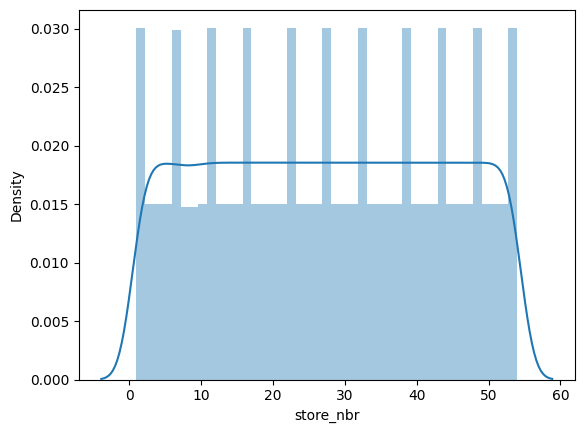

In [10]:
sns.distplot(data['store_nbr'])

In [11]:
data['date'] = data['date'].fillna(data['date'].mode()[0])

In [12]:
data['store_nbr'] = data['store_nbr'].fillna(data['store_nbr'].mode()[0])

In [13]:
data['family'] = data['family'].fillna(data['family'].mode()[0])

In [14]:
data['sales'] = data['sales'].fillna(data['sales'].mode()[0])

In [15]:
data['onpromotion'] = data['onpromotion'].fillna(data['onpromotion'].mode()[0])

In [16]:
data.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


In [17]:
data.nunique()

,0
id,81886
date,46
store_nbr,54
family,33
sales,12706
onpromotion,1


In [18]:
data['store_nbr'].unique()

array([ 1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,  2, 20, 21, 22, 23, 24,
       25, 26, 27, 28, 29,  3, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,  4,
       40, 41, 42, 43, 44, 45, 46, 47, 48, 49,  5, 50, 51, 52, 53, 54,  6,
        7,  8,  9])

In [19]:
data['onpromotion'].value_counts()

,count
onpromotion,
0.0,81886


In [20]:
data.dtypes

,0
id,int64
date,object
store_nbr,int64
family,object
sales,float64
onpromotion,float64


In [21]:
data.duplicated().sum()

np.int64(0)

In [22]:
data["sales"].describe()

,sales
count,81886.000000
mean,190.048882
std,648.706204
min,0.000000
25%,0.000000
50%,0.000000
75%,83.000000
max,26067.000000


In [23]:
(data['sales'] < 3000).sum()

np.int64(80998)

<Axes: >

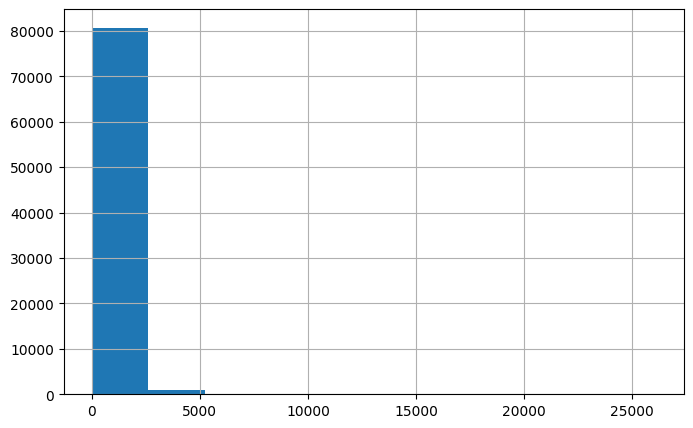

In [24]:
data["sales"].hist(figsize=(8,5))

/tmp/ipykernel_1492/1715658358.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['sales'])


<Axes: xlabel='sales', ylabel='Density'>

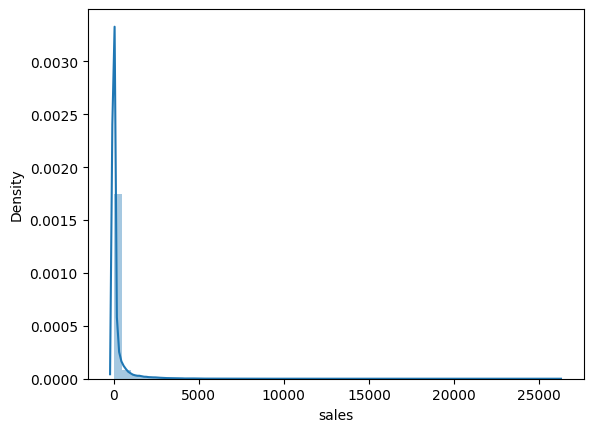

In [25]:
sns.distplot(data['sales'])

In [26]:
data.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')

In [27]:
 data.dtypes

,0
id,int64
date,object
store_nbr,int64
family,object
sales,float64
onpromotion,float64


In [28]:
mask = data['date']=='2013-01-01'

In [29]:
mask.count()

np.int64(81886)

In [30]:
data['date'].nunique()

46

In [31]:
mask = data["date"] == "2013-01-01"

In [32]:
type(mask)

pandas.core.series.Series

In [33]:
mask.sum()

np.int64(1782)

In [34]:
print(data["date"].dtype)

object


In [35]:
data["date"] = pd.to_datetime(data["date"], errors="coerce")

In [36]:
print(data["date"].dtype)

datetime64[ns]


In [37]:
# ============================
# 8. Rows for Store 1 on 2013-01-01
# ============================

store1 = data[
    (data["store_nbr"] == 1) &
    (data["date"] == "2013-01-01")
]

print(store1)
print("Total Records:", len(store1))

    id       date  store_nbr                      family  sales  onpromotion
0    0 2013-01-01          1                  AUTOMOTIVE    0.0          0.0
1    1 2013-01-01          1                   BABY CARE    0.0          0.0
2    2 2013-01-01          1                      BEAUTY    0.0          0.0
3    3 2013-01-01          1                   BEVERAGES    0.0          0.0
4    4 2013-01-01          1                       BOOKS    0.0          0.0
5    5 2013-01-01          1                BREAD/BAKERY    0.0          0.0
6    6 2013-01-01          1                 CELEBRATION    0.0          0.0
7    7 2013-01-01          1                    CLEANING    0.0          0.0
8    8 2013-01-01          1                       DAIRY    0.0          0.0
9    9 2013-01-01          1                        DELI    0.0          0.0
10  10 2013-01-01          1                        EGGS    0.0          0.0
11  11 2013-01-01          1                FROZEN FOODS    0.0          0.0

In [38]:
# ============================
# 9. Highest Selling Product Family
# ============================

family_sales = (
    data.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
)

print(family_sales)

print("\nHighest Selling Family:")
print(family_sales.head(1))

family
GROCERY I                     6.153384e+06
BEVERAGES                     2.474115e+06
CLEANING                      2.169922e+06
BREAD/BAKERY                  8.111761e+05
MEATS                         7.931094e+05
DAIRY                         7.902680e+05
PERSONAL CARE                 4.694170e+05
POULTRY                       4.602849e+05
DELI                          4.563723e+05
EGGS                          3.051920e+05
PREPARED FOODS                2.051979e+05
FROZEN FOODS                  1.709279e+05
LIQUOR,WINE,BEER              1.564480e+05
SEAFOOD                       5.219518e+04
GROCERY II                    4.023400e+04
LINGERIE                      2.878800e+04
AUTOMOTIVE                    1.064600e+04
BEAUTY                        6.138000e+03
LAWN AND GARDEN               5.915000e+03
HARDWARE                      2.368000e+03
HOME APPLIANCES               2.440000e+02
BABY CARE                     0.000000e+00
HOME AND KITCHEN I            0.000000e+00
BOOK

In [39]:
# ============================
# 10. Average Sales by Store
# ============================

store_sales = (
    data.groupby("store_nbr")["sales"]
    .mean()
    .sort_values(ascending=False)
)

print(store_sales)

store_nbr
44    663.417236
45    537.007904
47    522.073784
46    482.487308
3     475.862281
48    396.784556
51    347.474176
50    341.874669
11    330.082966
8     304.399389
24    284.639088
49    284.210936
9     279.022477
6     265.590421
7     234.675249
37    222.085812
2     212.074410
5     204.373995
38    202.570567
4     201.666484
34    189.778453
39    183.337393
25    176.255470
17    164.036999
31    161.700526
27    161.403096
23    152.758770
14    152.752123
1     146.752547
33    144.307088
16    139.959984
18    137.269442
43    129.016996
28    128.516192
19    128.053059
15    127.644855
40    124.949111
12    123.215008
13    118.350378
10    117.608997
26    115.448914
41    115.134056
54    111.455196
35     85.107265
30     70.618920
32     69.843119
22      0.000000
21      0.000000
20      0.000000
29      0.000000
36      0.000000
42      0.000000
52      0.000000
53      0.000000
Name: sales, dtype: float64


In [40]:
# ============================
# 11. Top 10 Stores by Total Sales
# ============================

top10 = (
    data.groupby("store_nbr")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top10)

store_nbr
44    1.007067e+06
45    8.151780e+05
47    7.925080e+05
46    7.324157e+05
3     7.223589e+05
48    6.023190e+05
51    5.274658e+05
50    5.189657e+05
11    5.010659e+05
8     4.520331e+05
Name: sales, dtype: float64


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

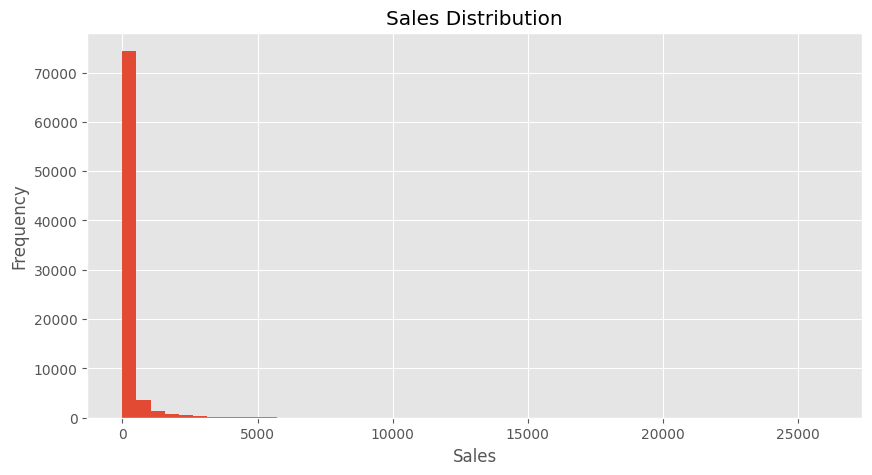

In [42]:
plt.figure(figsize=(10,5))
plt.hist(data["sales"], bins=50)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

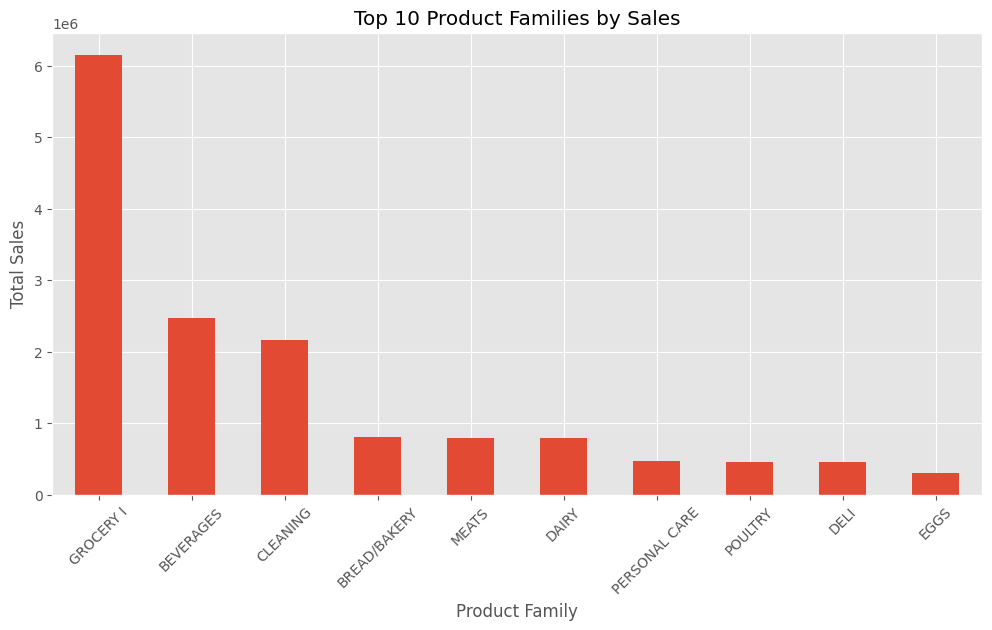

In [43]:
family_sales = (
    data.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
family_sales.plot(kind="bar")
plt.title("Top 10 Product Families by Sales")
plt.xlabel("Product Family")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

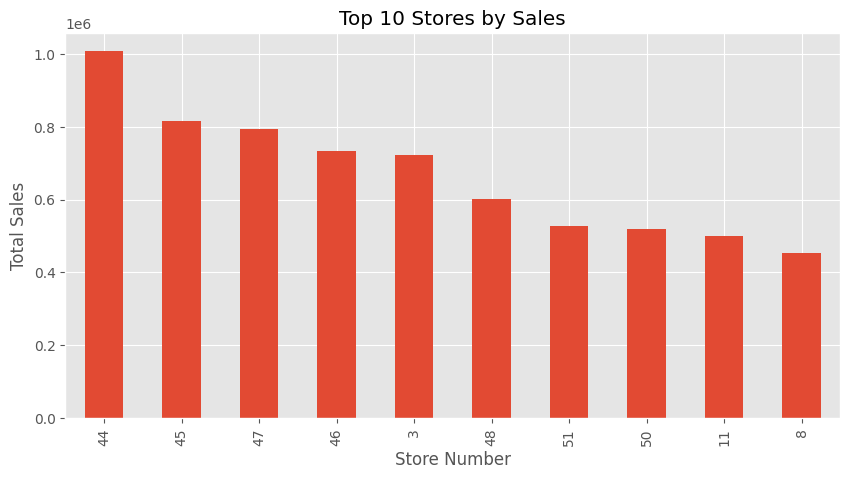

In [44]:
store_sales = (
    data.groupby("store_nbr")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
store_sales.plot(kind="bar")
plt.title("Top 10 Stores by Sales")
plt.xlabel("Store Number")
plt.ylabel("Total Sales")
plt.show()

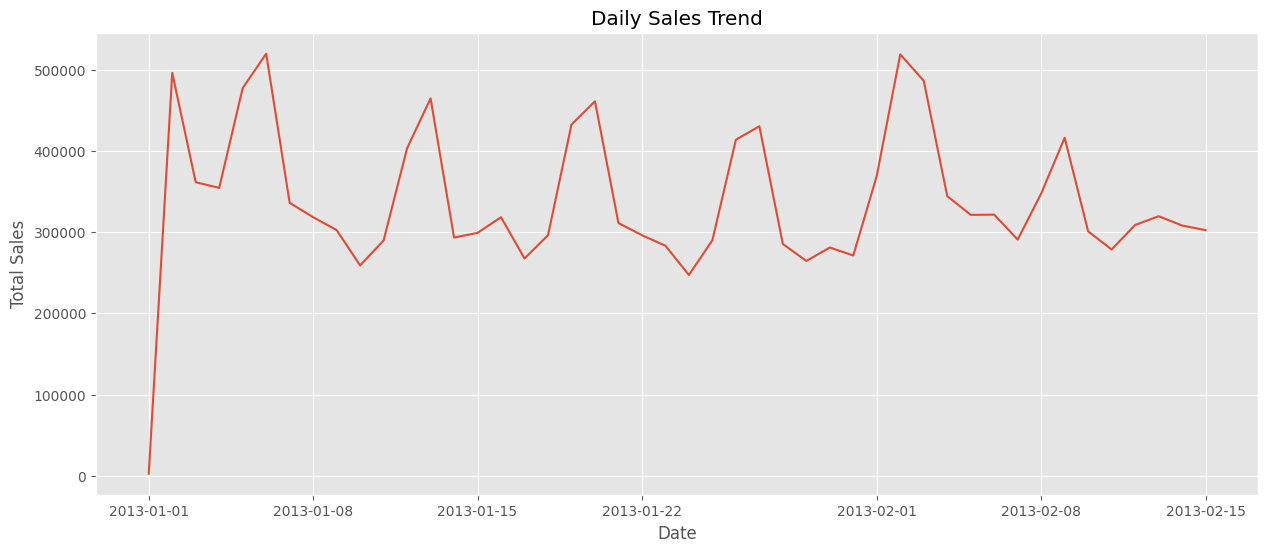

In [45]:
daily_sales = (
    data.groupby("date")["sales"]
    .sum()
)

plt.figure(figsize=(15,6))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

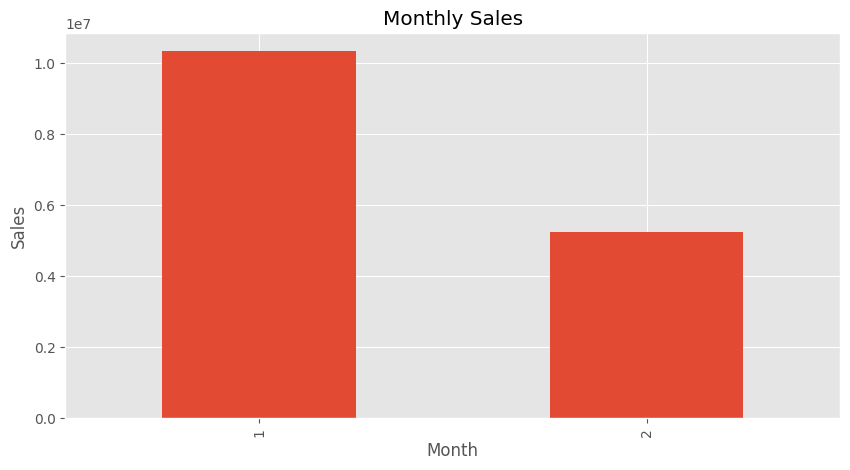

In [46]:
monthly_sales = (data.groupby(data["date"].dt.month)["sales"].sum())

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="bar")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

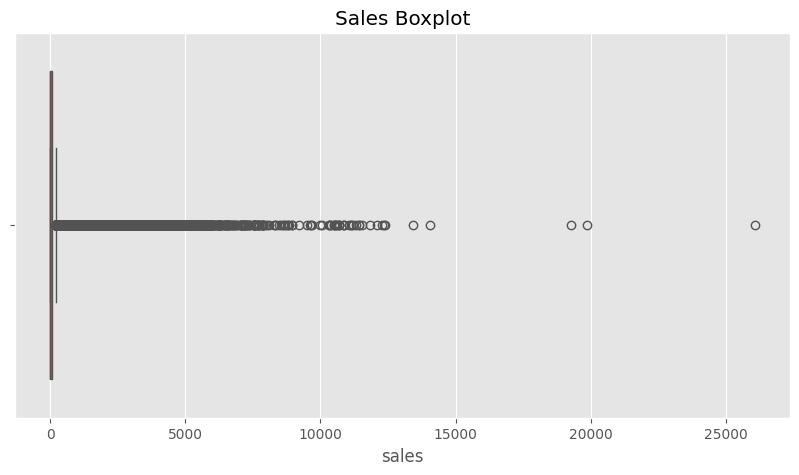

In [47]:
plt.figure(figsize=(10,5))
sns.boxplot(x=data["sales"])
plt.title("Sales Boxplot")
plt.show()

In [48]:
# Create time-based features

data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day
data["day_of_week"] = data["date"].dt.dayofweek
data["week_of_year"] = data["date"].dt.isocalendar().week.astype(int)
data["quarter"] = data["date"].dt.quarter
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)

data.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,day_of_week,week_of_year,quarter,is_weekend
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0.0,2013,1,1,1,1,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0.0,2013,1,1,1,1,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0.0,2013,1,1,1,1,1,0
3,3,2013-01-01,1,BEVERAGES,0.0,0.0,2013,1,1,1,1,1,0
4,4,2013-01-01,1,BOOKS,0.0,0.0,2013,1,1,1,1,1,0


In [49]:
# Drop columns not useful for model training

data.drop(columns=["id"], inplace=True)

# Remove onpromotion if it has only one unique value
if data["onpromotion"].nunique() == 1:
    data.drop(columns=["onpromotion"], inplace=True)

data.head()

,date,store_nbr,family,sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend
0,2013-01-01,1,AUTOMOTIVE,0.0,2013,1,1,1,1,1,0
1,2013-01-01,1,BABY CARE,0.0,2013,1,1,1,1,1,0
2,2013-01-01,1,BEAUTY,0.0,2013,1,1,1,1,1,0
3,2013-01-01,1,BEVERAGES,0.0,2013,1,1,1,1,1,0
4,2013-01-01,1,BOOKS,0.0,2013,1,1,1,1,1,0


In [50]:
print(data.columns)

print("\nShape:", data.shape)

data.info()

Index(['date', 'store_nbr', 'family', 'sales', 'year', 'month', 'day',
       'day_of_week', 'week_of_year', 'quarter', 'is_weekend'],
      dtype='object')

Shape: (81886, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81886 entries, 0 to 81885
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          81886 non-null  datetime64[ns]
 1   store_nbr     81886 non-null  int64         
 2   family        81886 non-null  object        
 3   sales         81886 non-null  float64       
 4   year          81886 non-null  int32         
 5   month         81886 non-null  int32         
 6   day           81886 non-null  int32         
 7   day_of_week   81886 non-null  int32         
 8   week_of_year  81886 non-null  int64         
 9   quarter       81886 non-null  int32         
 10  is_weekend    81886 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int32(5), int64(3), objec

In [51]:
data = pd.get_dummies(
    data,
    columns=["family"],
    drop_first=True,
    dtype=int
)

data.head()

,date,store_nbr,sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend,...,family_MAGAZINES,family_MEATS,family_PERSONAL CARE,family_PET SUPPLIES,family_PLAYERS AND ELECTRONICS,family_POULTRY,family_PREPARED FOODS,family_PRODUCE,family_SCHOOL AND OFFICE SUPPLIES,family_SEAFOOD
0,2013-01-01,1,0.0,2013,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2013-01-01,1,0.0,2013,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,2013-01-01,1,0.0,2013,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,2013-01-01,1,0.0,2013,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2013-01-01,1,0.0,2013,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
print(data.shape)

data.info()

(81886, 42)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81886 entries, 0 to 81885
Data columns (total 42 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   date                               81886 non-null  datetime64[ns]
 1   store_nbr                          81886 non-null  int64         
 2   sales                              81886 non-null  float64       
 3   year                               81886 non-null  int32         
 4   month                              81886 non-null  int32         
 5   day                                81886 non-null  int32         
 6   day_of_week                        81886 non-null  int32         
 7   week_of_year                       81886 non-null  int64         
 8   quarter                            81886 non-null  int32         
 9   is_weekend                         81886 non-null  int64         
 10  family_BABY CARE      

In [53]:
data = data.sort_values("date").reset_index(drop=True)

In [54]:
X = data.drop(columns=["sales", "date"])
y = data["sales"]

print(X.shape)
print(y.shape)

(81886, 40)
(81886,)


In [55]:
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (65508, 40)
Testing Samples  : (16378, 40)


In [56]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [57]:
predictions = model.predict(X_test)

In [58]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 47.39388658241958
RMSE: 269.80701281275856
R²  : 0.8027323751755155


In [59]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(15))

                 Feature  Importance
19      family_GROCERY I    0.386793
0              store_nbr    0.368239
10      family_BEVERAGES    0.057023
14       family_CLEANING    0.047581
3                    day    0.040336
4            day_of_week    0.039220
7             is_weekend    0.025419
5           week_of_year    0.008212
12   family_BREAD/BAKERY    0.005392
31          family_MEATS    0.005329
15          family_DAIRY    0.005319
2                  month    0.003612
32  family_PERSONAL CARE    0.001933
35        family_POULTRY    0.001923
16           family_DELI    0.001907


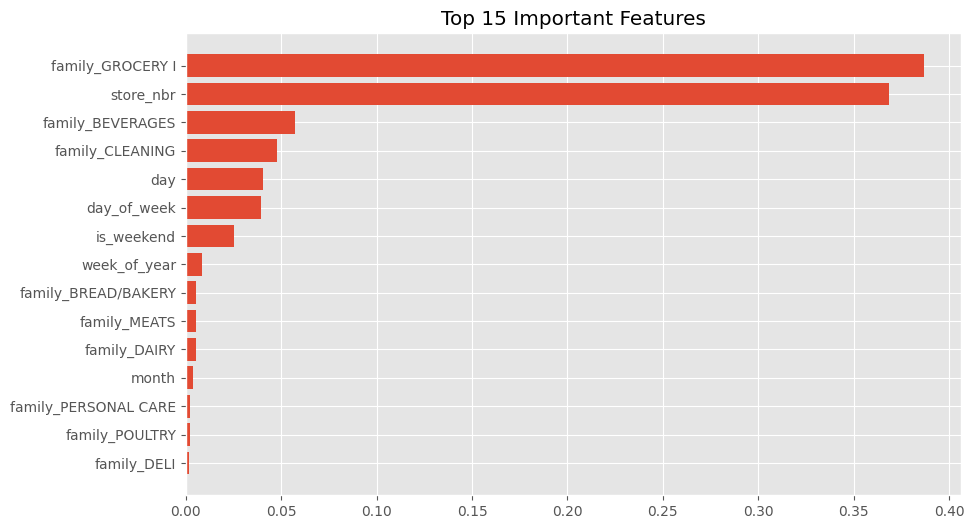

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

In [61]:
!pip install xgboost -q

In [62]:
from xgboost import XGBRegressor

In [63]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [64]:
xgb_predictions = xgb_model.predict(X_test)

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, xgb_predictions)
rmse = mean_squared_error(y_test, xgb_predictions) ** 0.5
r2 = r2_score(y_test, xgb_predictions)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 52.7020
RMSE : 254.3968
R²   : 0.8246


In [66]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

                              Feature  Importance
19                   family_GROCERY I    0.595893
10                   family_BEVERAGES    0.097303
14                    family_CLEANING    0.085607
38  family_SCHOOL AND OFFICE SUPPLIES    0.018453
0                           store_nbr    0.017248
13                 family_CELEBRATION    0.016423
31                       family_MEATS    0.014628
11                       family_BOOKS    0.013205
15                       family_DAIRY    0.011410
34     family_PLAYERS AND ELECTRONICS    0.011369
12                family_BREAD/BAKERY    0.009847
37                     family_PRODUCE    0.009447
24             family_HOME APPLIANCES    0.008461
7                          is_weekend    0.007765
8                    family_BABY CARE    0.007420


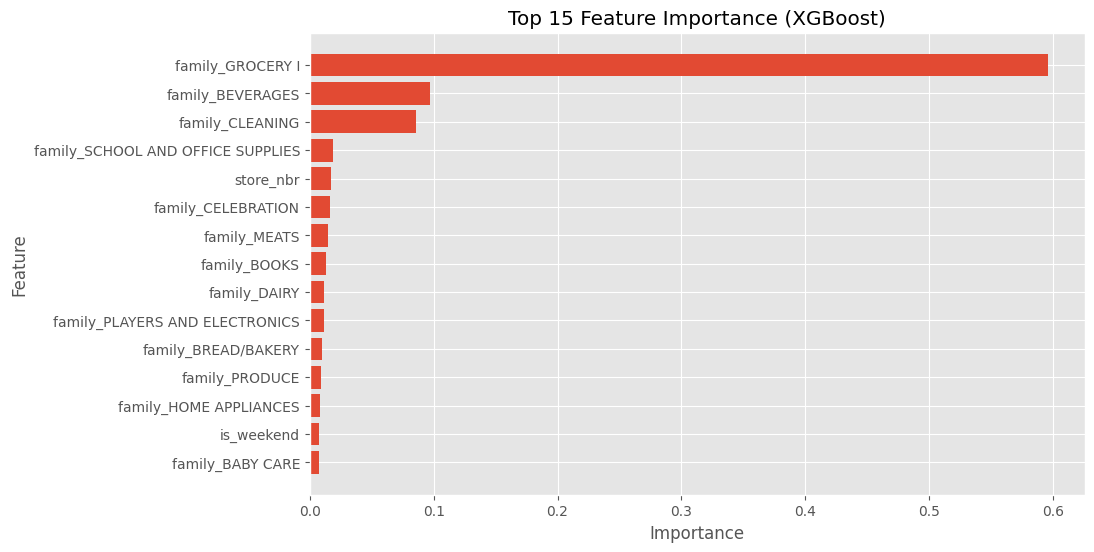

In [67]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [68]:
import joblib

joblib.dump(xgb_model, "sales_forecasting_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [69]:
data.to_csv("processed_sales_data.csv", index=False)

print("Processed dataset saved!")

Processed dataset saved!


In [70]:
results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": xgb_predictions
})

results.to_csv("sales_predictions.csv", index=False)

results.head()

,Actual Sales,Predicted Sales
0,0.0,32.573524
1,2759.0,2631.595215
2,5.0,38.782532
3,0.0,31.225311
4,4.0,38.803921


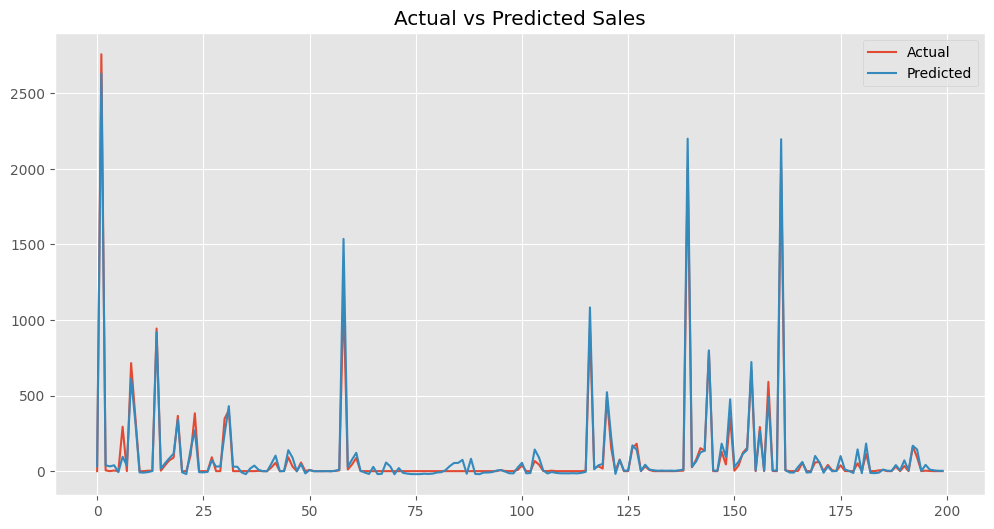

In [71]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label="Actual"
)

plt.plot(
    xgb_predictions[:200],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()